# GeoLife Dataset Inspection

This notebook explores the extracted GeoLife GPS trajectories for WEGOTCHU’s Phase 1 route-deviation research. It inspects the dataset structure, trajectory fields, data quality, sampling gaps, repeated trajectories, and available transportation-mode labels.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "geolife").is_dir():
            return candidate

    raise FileNotFoundError(
        "GeoLife dataset not found. Extract it under "
        "'data/raw/geolife/' in the repository, then run this notebook "
        "with Jupyter started from the repository or one of its subfolders."
    )


project_root = find_project_root(Path.cwd())
root = project_root / "data" / "raw" / "geolife"

trajectory_files = sorted(root.rglob("*.plt"))

if not trajectory_files:
    raise FileNotFoundError(
        "No .plt trajectory files were found under data/raw/geolife."
    )

user_directories = sorted({
    file.parent.parent.name
    for file in trajectory_files
})

print("Trajectory files:", len(trajectory_files))
print("User directories:", len(user_directories))
print(
    "Example trajectory:",
    trajectory_files[0].relative_to(project_root).as_posix()
)
print("Example user IDs:", user_directories[:10])

Trajectory files: 18670
User directories: 182
Example trajectory: data/raw/geolife/Geolife Trajectories 1.3/Data/000/Trajectory/20081023025304.plt
Example user IDs: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009']


## Dataset Inventory

Each `.plt` file contains a recorded GPS trajectory. Trajectory files are stored inside each user’s `Trajectory` folder. The counts above describe the extracted files; quality filtering may reduce the number usable in later experiments.

In [2]:
columns = [
    "latitude",
    "longitude",
    "unused",
    "altitude_feet",
    "days",
    "date",
    "time",
]

sample_file = trajectory_files[0]

sample_df = pd.read_csv(
    sample_file,
    skiprows=6,
    header=None,
    names=columns,
)

sample_df["timestamp"] = pd.to_datetime(
    sample_df["date"].astype(str) + " " + sample_df["time"].astype(str),
    errors="coerce",
)

# GeoLife uses -777 as a missing-altitude sentinel. Altitude is recorded in feet.
sample_df["altitude_feet"] = sample_df["altitude_feet"].replace(
    -777, np.nan
)
sample_df["altitude_meters"] = sample_df["altitude_feet"] * 0.3048

print("Example trajectory rows and columns:", sample_df.shape)
display(sample_df.head())

Example trajectory rows and columns: (908, 9)


,latitude,longitude,unused,altitude_feet,days,date,time,timestamp,altitude_meters
0,39.984702,116.318417,0,492,39744.120185,2008-10-23,02:53:04,2008-10-23 02:53:04,149.9616
1,39.984683,116.318450,0,492,39744.120255,2008-10-23,02:53:10,2008-10-23 02:53:10,149.9616
2,39.984686,116.318417,0,492,39744.120313,2008-10-23,02:53:15,2008-10-23 02:53:15,149.9616
3,39.984688,116.318385,0,492,39744.120370,2008-10-23,02:53:20,2008-10-23 02:53:20,149.9616
4,39.984655,116.318263,0,492,39744.120428,2008-10-23,02:53:25,2008-10-23 02:53:25,149.9616


## Trajectory Fields and Altitude

The trajectory records provide latitude, longitude, altitude, date, and time. The notebook combines date and time into a timestamp. GeoLife records altitude in feet and uses `-777` to indicate missing altitude; this notebook converts valid altitude values to metres.

In [3]:
print("Column types:")
display(sample_df.dtypes)

print("Missing values:")
display(sample_df.isna().sum())

print("Duplicate rows:", sample_df.duplicated().sum())
print(
    "Duplicate timestamps:",
    sample_df["timestamp"].duplicated().sum()
)

invalid_latitude = (
    (sample_df["latitude"] < -90) |
    (sample_df["latitude"] > 90)
).sum()

invalid_longitude = (
    (sample_df["longitude"] < -180) |
    (sample_df["longitude"] > 180)
).sum()

print("Invalid latitude values:", invalid_latitude)
print("Invalid longitude values:", invalid_longitude)

Column types:


latitude                  float64
longitude                 float64
unused                      int64
altitude_feet               int64
days                      float64
date                          str
time                          str
timestamp          datetime64[us]
altitude_meters           float64
dtype: object

Missing values:


latitude           0
longitude          0
unused             0
altitude_feet      0
days               0
date               0
time               0
timestamp          0
altitude_meters    0
dtype: int64

Duplicate rows: 0
Duplicate timestamps: 0
Invalid latitude values: 0
Invalid longitude values: 0


## Timestamp Gaps

Sampling intervals can vary within a trajectory. The following checks measure the time between consecutive observations. Large gaps should be treated as breaks in the recorded track during later preprocessing.

In [4]:
ordered = sample_df.sort_values("timestamp").copy()

gaps = (
    ordered["timestamp"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

display(gaps.describe())
print("Gaps greater than 60 seconds:", (gaps > 60).sum())
print("Gaps greater than 5 minutes:", (gaps > 300).sum())
print("Largest gap in seconds:", gaps.max())

count      907.000000
mean        32.952591
std        627.101101
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      18453.000000
Name: timestamp, dtype: float64

Gaps greater than 60 seconds: 9
Gaps greater than 5 minutes: 6
Largest gap in seconds: 18453.0


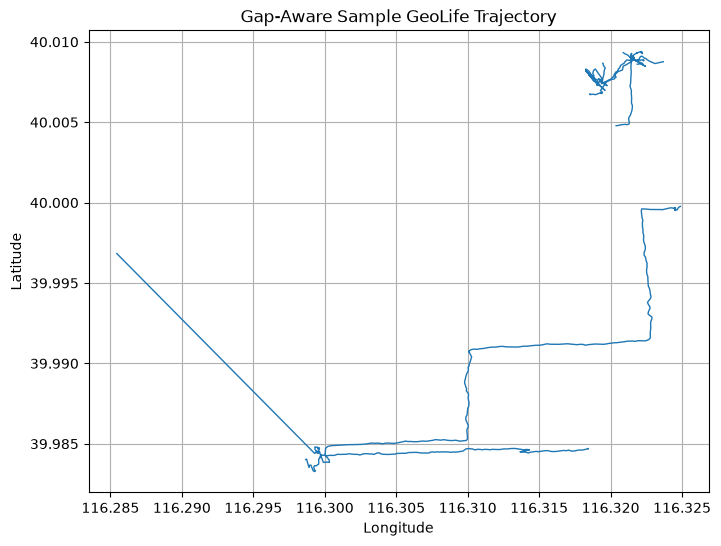

In [5]:
plot_df = sample_df.sort_values("timestamp").copy()

plot_df["gap_seconds"] = (
    plot_df["timestamp"]
    .diff()
    .dt.total_seconds()
)

plot_df.loc[
    plot_df["gap_seconds"] > 60,
    ["latitude", "longitude"]
] = np.nan

plt.figure(figsize=(8, 6))
plt.plot(
    plot_df["longitude"],
    plot_df["latitude"],
    linewidth=1,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Gap-Aware Sample GeoLife Trajectory")
plt.grid(True)
plt.show()

## Repeated Trajectories and Personalization

Users have unequal numbers of recorded trajectories. The following counts show how many users meet several possible minimum-history thresholds. Five trajectories is a provisional threshold for estimating how many users might support an initial personalized experiment; it is not yet a final model decision.

## Data Quality Findings

The inspected trajectory contains 908 observations with no missing values, duplicate rows, duplicate timestamps, or invalid coordinates.

However, timestamp intervals are irregular. Nine gaps exceed 60 seconds, six gaps exceed five minutes, and the largest gap is 18,453 seconds (approximately 5.1 hours). Therefore, preprocessing must detect large temporal gaps and must not connect points across such gaps as if continuous movement occurred.

In [6]:
trajectory_counts = (
    pd.Series(
        [file.parent.parent.name for file in trajectory_files],
        name="user_id",
    )
    .value_counts()
    .sort_index()
)

print("Number of users:", trajectory_counts.size)
print("Minimum trajectories per user:", trajectory_counts.min())
print("Median trajectories per user:", trajectory_counts.median())
print("Maximum trajectories per user:", trajectory_counts.max())

display(trajectory_counts.head(20))

for minimum in [2, 5, 10, 20]:
    usable_users = (trajectory_counts >= minimum).sum()
    print(
        f"Users with at least {minimum} trajectories: "
        f"{usable_users} / {len(trajectory_counts)}"
    )

Number of users: 182
Minimum trajectories per user: 1
Median trajectories per user: 27.5
Maximum trajectories per user: 2153


user_id
000    171
001     71
002    175
003    322
004    395
005     86
006     28
007     54
008     34
009     49
010    161
011    201
012     77
013    144
014    279
015     67
016     51
017    391
018     50
019     84
Name: count, dtype: int64

Users with at least 2 trajectories: 175 / 182
Users with at least 5 trajectories: 160 / 182
Users with at least 10 trajectories: 131 / 182
Users with at least 20 trajectories: 107 / 182


## Repeated Trajectory Availability

The dataset contains 182 users. The number of trajectories per user is highly unequal, ranging from 1 to 2,153, with a median of 27.5 trajectories per user.

This supports personalized modeling for users with sufficient historical trajectories, but users with very little history require a cold-start fallback. The experiment must report how many users meet the minimum-history requirement.

## Personalization Eligibility

Using a provisional minimum-history threshold of 5 trajectories, 160 of 182 users are eligible for personalized evaluation. The remaining 22 users do not have enough historical trajectories and should use a cold-start fallback.

The threshold of 5 is an initial experimental choice and must be reported clearly. It may be revised after preprocessing and baseline evaluation.

## Transportation-Mode Labels

Some users have `labels.txt` files containing time intervals and transportation-mode annotations. These labels are not safety, danger, or route-anomaly labels, and they are not available for every user.

In [7]:
label_files = sorted(root.rglob("labels.txt"))

print("Label files found:", len(label_files))

if label_files:
    print(
        "Example label file:",
        label_files[0].relative_to(project_root).as_posix()
    )
else:
    print("No labels.txt files were found.")

all_labels = []

for label_file in label_files:
    try:
        labels = pd.read_csv(
            label_file,
            sep="\t",
            header=0,
        )
        labels["user_id"] = label_file.parent.name
        all_labels.append(labels)
    except Exception as error:
        print(
            "Could not read a label file:",
            label_file.relative_to(project_root).as_posix(),
        )
        print(type(error).__name__, str(error))

if all_labels:
    labels_df = pd.concat(all_labels, ignore_index=True)

    print("Total label rows:", len(labels_df))
    print("Users with labels:", labels_df["user_id"].nunique())
    print("Columns:", labels_df.columns.tolist())
    display(labels_df.head())

    if "Transportation Mode" in labels_df.columns:
        print("Transportation modes:")
        display(labels_df["Transportation Mode"].value_counts())
else:
    labels_df = pd.DataFrame()
    print("No transportation-label rows were successfully read.")

Label files found: 69
Example label file: data/raw/geolife/Geolife Trajectories 1.3/Data/010/labels.txt
Total label rows: 14718
Users with labels: 69
Columns: ['Start Time', 'End Time', 'Transportation Mode', 'user_id']


,Start Time,End Time,Transportation Mode,user_id
0,2007/06/26 11:32:29,2007/06/26 11:40:29,bus,010
1,2008/03/28 14:52:54,2008/03/28 15:59:59,train,010
2,2008/03/28 16:00:00,2008/03/28 22:02:00,train,010
3,2008/03/29 01:27:50,2008/03/29 15:59:59,train,010
4,2008/03/29 16:00:00,2008/03/30 15:59:59,train,010


Transportation modes:


Transportation Mode
walk          6460
bus           2853
bike          2089
taxi          1179
car            993
subway         813
train          299
airplane        17
boat             7
run              6
motorcycle       2
Name: count, dtype: int64

## Inspection Summary

GeoLife provides repeated GPS trajectories for multiple users, with latitude, longitude, and timestamps available in the trajectory files. Sampling intervals vary, and some trajectories contain large gaps. The dataset also contains transportation-mode labels for a subset of users, but these are not safety labels. These findings support further route-deviation research, subject to preprocessing and evaluation decisions.